# Image Captioning - Inference And Analysis

This notebook demonstrates:
1. Loading trained artifacts
2. Generating captions for unseen images
3. Reviewing successful and unsuccessful examples
4. Basic score reporting (token-level overlap)

In [2]:
import json
import random
import re
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torchvision import models, transforms

In [4]:
@dataclass
class InferCFG:
    data_root: str = 'caption_data'
    images_dir_name: str = 'images'
    captions_file_name: str = 'captions.txt'

    artifacts_dir: str = 'artifacts'
    model_ckpt_name: str = 'best_model.pt'
    vocab_name: str = 'vocab.json'
    train_config_name: str = 'train_config.json'
    split_name: str = 'data_split.json'

    max_gen_len: int = 30
    inference_run_name: str = 'inference_run'

cfg = InferCFG()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

data_root = Path(cfg.data_root)
images_dir = data_root / cfg.images_dir_name
captions_path = data_root / cfg.captions_file_name

artifacts_dir = Path(cfg.artifacts_dir)
ckpt_path = artifacts_dir / cfg.model_ckpt_name
vocab_path = artifacts_dir / cfg.vocab_name
train_cfg_path = artifacts_dir / cfg.train_config_name
split_path = artifacts_dir / cfg.split_name

for p in [images_dir, captions_path, ckpt_path, vocab_path, train_cfg_path, split_path]:
    assert p.exists(), f'Missing required path: {p}'

inference_dir = artifacts_dir / cfg.inference_run_name
plots_dir = inference_dir / 'plots'
tables_dir = inference_dir / 'tables'
samples_dir = inference_dir / 'samples'
for p in [inference_dir, plots_dir, tables_dir, samples_dir]:
    p.mkdir(parents=True, exist_ok=True)

print('All required files are present.')
print('Inference directory:', inference_dir)

Device: cpu
All required files are present.
Inference directory: artifacts\inference_run


In [5]:
def parse_captions_file(captions_file: Path) -> pd.DataFrame:
    lines = captions_file.read_text(encoding='utf-8').splitlines()
    rows = []

    for line in lines:
        line = line.strip()
        if not line:
            continue

        lowered = line.lower()
        if lowered.startswith('image,caption') or lowered.startswith('image\tcaption'):
            continue

        image_name = None
        caption = None

        if '\t' in line:
            image_name, caption = line.split('\t', 1)
        elif ',' in line:
            image_name, caption = line.split(',', 1)

        if image_name is None or caption is None:
            continue

        image_name = image_name.strip()
        caption = caption.strip()

        if '#' in image_name:
            image_name = image_name.split('#', 1)[0].strip()

        rows.append((image_name, caption))

    df = pd.DataFrame(rows, columns=['image_name', 'caption'])
    df = df.dropna().reset_index(drop=True)
    return df

captions_df = parse_captions_file(captions_path)
captions_df['image_path'] = captions_df['image_name'].apply(lambda n: str(images_dir / n))
captions_df = captions_df[captions_df['image_path'].map(lambda p: Path(p).exists())].reset_index(drop=True)

split_payload = json.loads(split_path.read_text(encoding='utf-8'))
test_images = set(split_payload['test_images'])
test_df = captions_df[captions_df['image_name'].isin(test_images)].reset_index(drop=True)

print('Test rows:', len(test_df), '| test images:', test_df['image_name'].nunique())

Test rows: 4050 | test images: 810


In [6]:
vocab_payload = json.loads(vocab_path.read_text(encoding='utf-8'))
itos = vocab_payload['itos']
stoi = {k: int(v) for k, v in vocab_payload['stoi'].items()}

pad_id = vocab_payload['special_tokens']['pad_id']
bos_id = vocab_payload['special_tokens']['bos_id']
eos_id = vocab_payload['special_tokens']['eos_id']
unk_id = vocab_payload['special_tokens']['unk_id']

train_cfg = json.loads(train_cfg_path.read_text(encoding='utf-8'))
print('Vocab size:', len(itos))
print('Train config loaded from:', train_cfg_path)

Vocab size: 5156
Train config loaded from: artifacts\train_config.json


In [7]:
class EncoderCNN(nn.Module):
    def __init__(self, out_dim: int):
        super().__init__()
        weights = models.ResNet50_Weights.DEFAULT
        backbone = models.resnet50(weights=weights)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.proj = nn.Linear(in_features, out_dim)
        self.bn = nn.BatchNorm1d(out_dim)

    def forward(self, images):
        feats = self.backbone(images)
        feats = self.proj(feats)
        feats = self.bn(feats)
        return feats

class DecoderLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.img2h = nn.Linear(embed_dim, hidden_dim)
        self.img2c = nn.Linear(embed_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, image_embeds, input_ids):
        x = self.embedding(input_ids)
        x = self.dropout(x)

        h0 = torch.tanh(self.img2h(image_embeds)).unsqueeze(0)
        c0 = torch.tanh(self.img2c(image_embeds)).unsqueeze(0)

        outputs, _ = self.lstm(x, (h0, c0))
        logits = self.fc(outputs)
        return logits

class ImageCaptionModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.encoder = EncoderCNN(embed_dim)
        self.decoder = DecoderLSTM(vocab_size, embed_dim, hidden_dim, num_layers, dropout)

    def forward(self, images, input_ids):
        image_embeds = self.encoder(images)
        logits = self.decoder(image_embeds, input_ids)
        return logits

model = ImageCaptionModel(
    vocab_size=len(itos),
    embed_dim=int(train_cfg['embed_dim']),
    hidden_dim=int(train_cfg['hidden_dim']),
    num_layers=int(train_cfg['num_layers']),
    dropout=float(train_cfg['dropout'])
).to(device)

model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()

print('Model loaded from:', ckpt_path)

Model loaded from: artifacts\best_model.pt


In [8]:
eval_tfms = transforms.Compose([
    transforms.Resize((int(train_cfg['image_size']), int(train_cfg['image_size']))),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def tokenize(text: str):
    text = text.lower().strip()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.split()

def decode_ids(ids):
    words = []
    for i in ids:
        w = itos[i]
        if w in ('<bos>', '<pad>'):
            continue
        if w == '<eos>':
            break
        words.append(w)
    return ' '.join(words)

@torch.no_grad()
def generate_caption(image_path: Path, max_len: int = 30):
    img = Image.open(image_path).convert('RGB')
    x = eval_tfms(img).unsqueeze(0).to(device)

    image_emb = model.encoder(x)

    generated = [bos_id]
    for _ in range(max_len):
        inp = torch.tensor(generated, dtype=torch.long, device=device).unsqueeze(0)
        logits = model.decoder(image_emb, inp)
        next_id = int(logits[0, -1].argmax().item())
        generated.append(next_id)
        if next_id == eos_id:
            break

    return decode_ids(generated), img

def simple_overlap_score(pred: str, refs):
    pred_set = set(tokenize(pred))
    if not pred_set:
        return 0.0
    best = 0.0
    for r in refs:
        ref_set = set(tokenize(r))
        if not ref_set:
            continue
        score = len(pred_set & ref_set) / max(1, len(pred_set | ref_set))
        best = max(best, score)
    return best

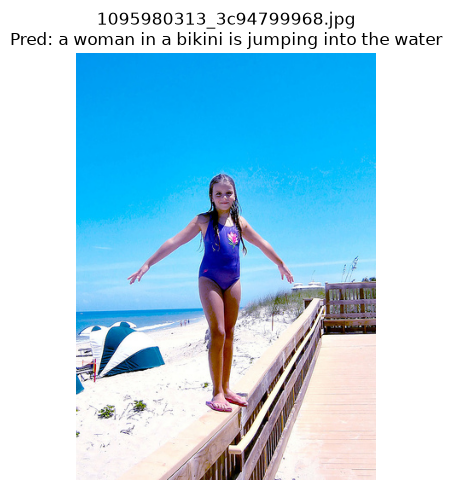

References:
- A little girl in a blue swimsuit is walking along a wooden fence next to a sandy beach .
- A little girl with arms outstretched is posing at the beach .
- A young girl walks on a railing in front of the beach .
- Little girl in blue swimsuit standing on a handrail near a beach .
- The little girl in the blue bathing suit is posing at the beach .
Overlap score: 0.176
--------------------------------------------------------------------------------


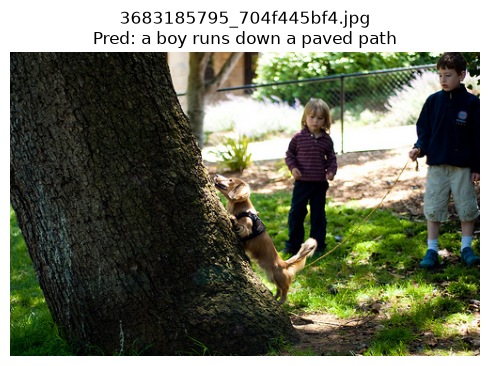

References:
- A girl and a boy watch a dog try to climb a tree .
- Boy and girl look on a puppy climbs tree
- The dog that the two children are walking is looking up at a tree .
- The two children watch the small yellow dog on the tree .
- Two children are with a dog on leash who is standing against a tree .
Overlap score: 0.154
--------------------------------------------------------------------------------


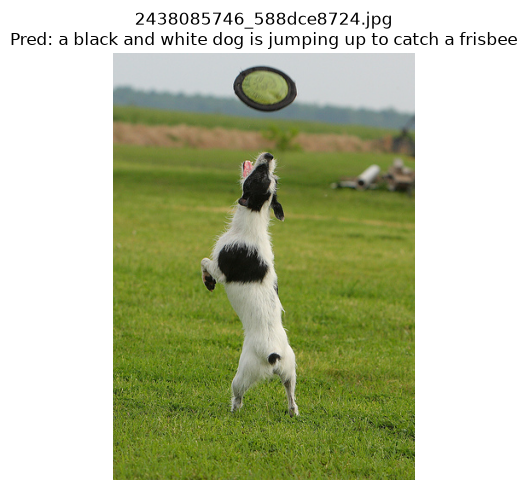

References:
- A black and white dog catc
- A black and white dog is playing with a Frisbee outside .
- A black and white dog jumps to catch the green Frisbee .
- A black and white dog leaps to catch a Frisbee in a field .
- A small black and white dog jumping on the grass to catch a Frisbee
Overlap score: 0.600
--------------------------------------------------------------------------------


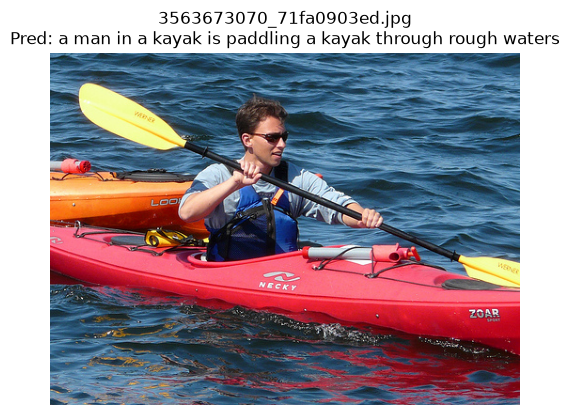

References:
- A kayaker in a red kayak paddles as an orange kayak approaches from behind .
- A man in a red kayak in the water .
- A man in a red kayak paddles through blue water .
- a man paddling a red kayak
- "Man paddles red kayak , orange kayak in background ."
Overlap score: 0.400
--------------------------------------------------------------------------------


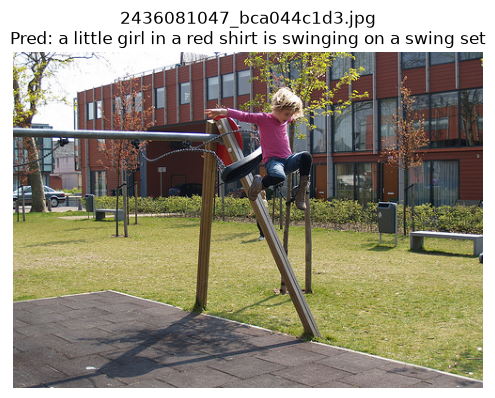

References:
- A girl dismounts from a swing as high as she can and lands on the rubber tiles below .
- A girl in a pink shirt jumping out of a moving swing .
- A little girl wearing a pink shirt jumps off a swing .
- A young girl jumps off a playground swing .
- The young girl in the pink shirt and blue jeans is jumping off the tire swing .
Overlap score: 0.333
--------------------------------------------------------------------------------


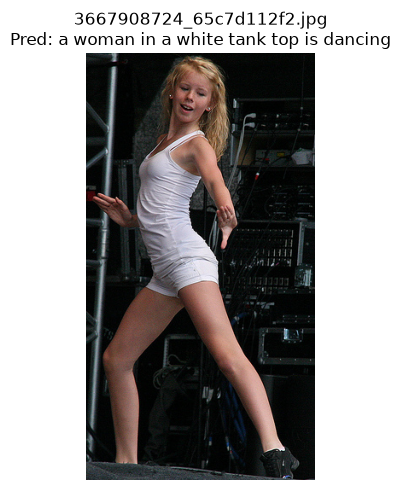

References:
- A girl dances on a stage .
- A girl dancing onstage .
- A girl in white dances .
- A young girl in a white dance outfit and black shoes is dancing in front of music equipment
- The blonde girl is dancing onstage in front of the sound equipment .
Overlap score: 0.300
--------------------------------------------------------------------------------


,image_name,prediction,references,overlap
0,1095980313_3c94799968.jpg,a woman in a bikini is jumping into the water,[A little girl in a blue swimsuit is walking a...,0.176471
1,3683185795_704f445bf4.jpg,a boy runs down a paved path,[A girl and a boy watch a dog try to climb a t...,0.153846
2,2438085746_588dce8724.jpg,a black and white dog is jumping up to catch a...,"[A black and white dog catc, A black and white...",0.600000
3,3563673070_71fa0903ed.jpg,a man in a kayak is paddling a kayak through r...,[A kayaker in a red kayak paddles as an orange...,0.400000
4,2436081047_bca044c1d3.jpg,a little girl in a red shirt is swinging on a ...,[A girl dismounts from a swing as high as she ...,0.333333
5,3667908724_65c7d112f2.jpg,a woman in a white tank top is dancing,"[A girl dances on a stage ., A girl dancing on...",0.300000


In [13]:
# Try random unseen test images
unique_test_images = sorted(test_df['image_name'].unique().tolist())
n_show = min(6, len(unique_test_images))
chosen = random.sample(unique_test_images, n_show) if n_show > 0 else []

records = []
for name in chosen:
    img_path = images_dir / name
    refs = test_df[test_df['image_name'] == name]['caption'].tolist()
    pred, img = generate_caption(img_path, max_len=cfg.max_gen_len)
    overlap = simple_overlap_score(pred, refs)

    records.append({
        'image_name': name,
        'prediction': pred,
        'references': refs,
        'overlap': overlap
    })

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'{name}\nPred: {pred}')
    plt.tight_layout()
    plt.savefig(samples_dir / f'sample_{name}.png', dpi=180)
    plt.show()

    print('References:')
    for r in refs:
        print('-', r)
    print(f'Overlap score: {overlap:.3f}')
    print('-' * 80)

results_df = pd.DataFrame(records)
results_df.to_csv(tables_dir / 'sample_predictions.csv', index=False)
(inference_dir / 'sample_predictions.json').write_text(results_df.to_json(orient='records', indent=2), encoding='utf-8')
results_df

Average overlap on sampled test images: 0.3959

Example success case:
Image: 3712742641_641282803e.jpg
Prediction: a black and white dog is standing in a stream
Overlap: 0.6364

Example failure case:
Image: 3231751379_10ebf7150c.jpg
Prediction: hockey players on a hockey game
Overlap: 0.2222


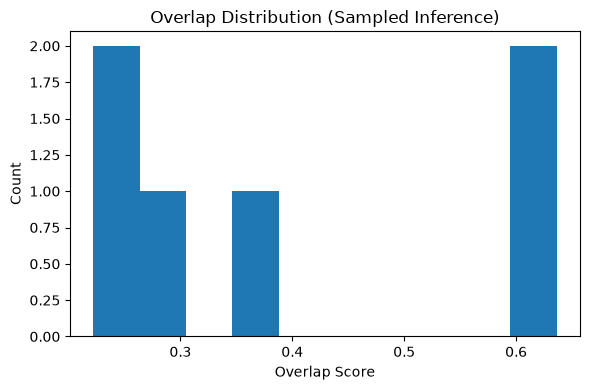

In [11]:
if len(results_df) > 0:
    print('Average overlap on sampled test images:', round(results_df['overlap'].mean(), 4))

    best_row = results_df.sort_values('overlap', ascending=False).iloc[0]
    worst_row = results_df.sort_values('overlap', ascending=True).iloc[0]

    summary = {
        'num_samples': int(len(results_df)),
        'avg_overlap': float(results_df['overlap'].mean()),
        'best_image': str(best_row['image_name']),
        'best_prediction': str(best_row['prediction']),
        'best_overlap': float(best_row['overlap']),
        'worst_image': str(worst_row['image_name']),
        'worst_prediction': str(worst_row['prediction']),
        'worst_overlap': float(worst_row['overlap'])
    }
    (inference_dir / 'inference_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
    pd.DataFrame([summary]).to_csv(tables_dir / 'inference_summary.csv', index=False)

    error_df = results_df.sort_values('overlap', ascending=True).copy()
    error_df.to_csv(tables_dir / 'error_analysis_sorted.csv', index=False)

    print('\nExample success case:')
    print('Image:', best_row['image_name'])
    print('Prediction:', best_row['prediction'])
    print('Overlap:', round(float(best_row['overlap']), 4))

    print('\nExample failure case:')
    print('Image:', worst_row['image_name'])
    print('Prediction:', worst_row['prediction'])
    print('Overlap:', round(float(worst_row['overlap']), 4))

    plt.figure(figsize=(6, 4))
    plt.hist(results_df['overlap'].values, bins=10)
    plt.title('Overlap Distribution (Sampled Inference)')
    plt.xlabel('Overlap Score')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(plots_dir / 'overlap_distribution.png', dpi=180)
    plt.show()
else:
    empty_summary = {'num_samples': 0, 'note': 'No test images found.'}
    (inference_dir / 'inference_summary.json').write_text(json.dumps(empty_summary, indent=2), encoding='utf-8')
    pd.DataFrame([empty_summary]).to_csv(tables_dir / 'inference_summary.csv', index=False)
    print('No test images found. Confirm your training notebook created artifacts and splits.')

In [12]:
# Stronger caption quality metrics: BLEU-1..4 (with smoothing) and ROUGE-L (LCS-based F1).
def _ngram_counts(tokens, n):
    counts = {}
    if len(tokens) < n:
        return counts
    for i in range(len(tokens) - n + 1):
        ng = tuple(tokens[i:i+n])
        counts[ng] = counts.get(ng, 0) + 1
    return counts

def _modified_precision(pred_tokens, ref_tokens_list, n):
    pred_counts = _ngram_counts(pred_tokens, n)
    if not pred_counts:
        return 0.0
    max_ref_counts = {}
    for ref_tokens in ref_tokens_list:
        ref_counts = _ngram_counts(ref_tokens, n)
        for ng, c in ref_counts.items():
            if c > max_ref_counts.get(ng, 0):
                max_ref_counts[ng] = c
    clipped = 0
    total = 0
    for ng, c in pred_counts.items():
        clipped += min(c, max_ref_counts.get(ng, 0))
        total += c
    return clipped / max(1, total)

def sentence_bleu_n(pred, refs, max_n=4, smooth=1e-9):
    pred_tokens = tokenize(pred)
    refs_tokens = [tokenize(r) for r in refs if tokenize(r)]
    if not pred_tokens or not refs_tokens:
        return {f'bleu_{n}': 0.0 for n in range(1, max_n + 1)}

    precisions = []
    for n in range(1, max_n + 1):
        p_n = _modified_precision(pred_tokens, refs_tokens, n)
        precisions.append(max(smooth, p_n))

    ref_lens = [len(r) for r in refs_tokens]
    pred_len = len(pred_tokens)
    closest_ref_len = min(ref_lens, key=lambda rl: (abs(rl - pred_len), rl))
    bp = 1.0 if pred_len > closest_ref_len else np.exp(1 - (closest_ref_len / max(1, pred_len)))

    bleu_scores = {}
    for n in range(1, max_n + 1):
        score = bp * np.exp(np.mean(np.log(precisions[:n])))
        bleu_scores[f'bleu_{n}'] = float(score)
    return bleu_scores

def _lcs_len(a, b):
    # Dynamic programming LCS length for ROUGE-L
    m, n = len(a), len(b)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(1, m + 1):
        ai = a[i - 1]
        for j in range(1, n + 1):
            if ai == b[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
    return dp[m][n]

def rouge_l_f1(pred, refs):
    pred_tokens = tokenize(pred)
    if not pred_tokens:
        return 0.0
    best = 0.0
    for r in refs:
        ref_tokens = tokenize(r)
        if not ref_tokens:
            continue
        lcs = _lcs_len(pred_tokens, ref_tokens)
        p = lcs / max(1, len(pred_tokens))
        rr = lcs / max(1, len(ref_tokens))
        f1 = 0.0 if (p + rr) == 0 else (2 * p * rr) / (p + rr)
        best = max(best, f1)
    return float(best)

@torch.no_grad()
def evaluate_on_test_set(max_images=None, seed=42):
    unique_images = sorted(test_df['image_name'].unique().tolist())
    if max_images is not None and max_images < len(unique_images):
        rng = random.Random(seed)
        unique_images = rng.sample(unique_images, max_images)

    rows = []
    for image_name in unique_images:
        image_path = images_dir / image_name
        refs = test_df[test_df['image_name'] == image_name]['caption'].tolist()
        pred, _ = generate_caption(image_path, max_len=cfg.max_gen_len)

        overlap = simple_overlap_score(pred, refs)
        bleu = sentence_bleu_n(pred, refs, max_n=4)
        rouge = rouge_l_f1(pred, refs)

        rows.append({
            'image_name': image_name,
            'prediction': pred,
            'references': refs,
            'overlap': overlap,
            'bleu_1': bleu['bleu_1'],
            'bleu_2': bleu['bleu_2'],
            'bleu_3': bleu['bleu_3'],
            'bleu_4': bleu['bleu_4'],
            'rouge_l_f1': rouge
        })

    df = pd.DataFrame(rows)
    return df

# Use all test images for final evaluation. If runtime is high, set max_images=300 for a fast proxy.
full_eval_df = evaluate_on_test_set(max_images=None)
full_eval_path_csv = tables_dir / 'full_test_evaluation.csv'
full_eval_path_json = inference_dir / 'full_test_evaluation.json'
full_eval_df.to_csv(full_eval_path_csv, index=False)
full_eval_path_json.write_text(full_eval_df.to_json(orient='records', indent=2), encoding='utf-8')

metrics_summary = {
    'num_test_images_evaluated': int(len(full_eval_df)),
    'overlap_mean': float(full_eval_df['overlap'].mean()),
    'bleu_1_mean': float(full_eval_df['bleu_1'].mean()),
    'bleu_2_mean': float(full_eval_df['bleu_2'].mean()),
    'bleu_3_mean': float(full_eval_df['bleu_3'].mean()),
    'bleu_4_mean': float(full_eval_df['bleu_4'].mean()),
    'rouge_l_f1_mean': float(full_eval_df['rouge_l_f1'].mean())
}
metrics_summary_path = inference_dir / 'advanced_metrics_summary.json'
metrics_summary_path.write_text(json.dumps(metrics_summary, indent=2), encoding='utf-8')

print('Saved full evaluation to:', full_eval_path_csv)
print('Saved full evaluation JSON to:', full_eval_path_json)
print('Saved metrics summary to:', metrics_summary_path)
pd.DataFrame([metrics_summary])

Saved full evaluation to: artifacts\inference_run\tables\full_test_evaluation.csv
Saved full evaluation JSON to: artifacts\inference_run\full_test_evaluation.json
Saved metrics summary to: artifacts\inference_run\advanced_metrics_summary.json


,num_test_images_evaluated,overlap_mean,bleu_1_mean,bleu_2_mean,bleu_3_mean,bleu_4_mean,rouge_l_f1_mean
0,810,0.289076,0.555496,0.359027,0.193815,0.093673,0.422326


## Notes For Your Report

- Explain where the model performs well (clear objects/scenes) and where it fails (complex interactions, rare words).
- Include visual examples with both prediction and multiple human references.
- Discuss improvements: attention decoder, beam search, stronger text decoder, more epochs, unfreezing encoder, BLEU/CIDEr metrics.